# Is firing the CEO good news or bad news for the stock? 👔
### The oldest argument on the trading floor, settled with a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Good_or_bad%3F: Busted](https://img.shields.io/badge/Good_or_bad%3F-Busted-8b949e?style=flat-square)

When a board pushes out its CEO, two camps shout past each other. **"Buy it"** — the underperformer is gone, the activists won, here comes the relief rally. **"Sell it"** — leadership chaos, uncertainty, who's steering the ship now? Both sound obvious. They can't both be right.

So we did the boring thing: take ~25 real, dated large-cap CEO changes — tagged **forced** (shown the door) or **planned** (orderly hand-off) — and measure exactly what the stock did around each one, *after subtracting out whatever the whole market did that day*. The answer is a little surprising, and a lot humbling.

> 📓 **Plain-language layer.** Want the market-model math, the *t*-stats and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Real CEO-turnover databases aren't free, so we **hardcode a transparent table** of well-known changes (and label each forced/planned ourselves — a judgement call at the edges, which we flag). Two delisted names drop out. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ceo_turnover import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS)            # canonical CAR[0,+2]
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| events with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-22', 'n_table': 26, 'n_used': 23, 'n_forced': 11, 'n_planned': 12, 'fingerprint': '2b48ba1b75f8', 'forced': (11, 1.02, 45, 0.63), 'planned': (12, -0.45, 42, -0.43), 'allb': (23, 0.25, 43, 0.27), 'diff_pp': 1.47, 'diff_t': 0.76, 'forced_placebo_p': 0.246, 'day0': (2.05, 1.95, 2.43, 0.007), 'lag1': (-0.81, -0.7, -0.47, -0.91), 'robust': [('[0,0]', 2.05, 1.95, 2.7, 2.43), ('[0,+2]', 1.02, 0.63, 1.47, 0.76), ('[-1,+1]', 2.44, 1.33, 3.04, 1.48), ('[0,+4]', 1.52, 0.73, 2.22, 0.87)], 'syn': [(0.0, -0.95, -1.51, -0.24, -0.64), (500.0, 4.05, 6.41, -0.24, 3.87)]}


real price cache present: True | events with data: 23


## The answer first

| Question | Answer |
|---|---|
| Does a *forced* ouster move the stock? | **Yes — on day one.** Forced-CEO stocks jump about **+2.0%** the day the news lands (a real, significant pop). |
| Great — can I trade that? | **No.** That jump is the price *instantly* re-rating on the news. By the time you can buy (the next day), it's already in the price — and what follows is **-0.8%** of nothing. |
| Is *planned* succession different? | **Barely.** A planned hand-off is a shrug (**-0.5%**). Forced minus planned over a holdable window is **+1.5 points** — but that gap is **statistically indistinguishable from luck** with so few events. |
| So… good news or bad news? | **Neither, reliably.** The only dependable move is the day-one jump you can't catch. Everything you *could* trade is noise of either sign. |

> Firing the CEO is real news — the market reacts in the first minutes. But "react" isn't "tradable," and ~a dozen examples per camp can't tell good from bad.

## 1 · The claim

> *"When the board fires an underperforming CEO, the stock pops — buy the relief."*  
> *"When a CEO is forced out, it's chaos — sell the uncertainty."*

Both are repeated as floor wisdom, often about the *same* event. The seduction is that a CEO change is a **clean, dated catalyst**: you know the day, you know the direction (someone got fired), so surely there's a trade. We'll take that seriously and measure the **abnormal return** — the stock's move *minus the market's* — around each announcement, split by whether the exit was forced or planned.

## 2 · So what?

Two different questions hide inside "does firing the CEO move the stock," and only one of them is tradable. (1) *Does the price react to the news?* — almost certainly yes; markets reprice on information. (2) *Is there a move left **for you** after the news is public?* — that's the only one that pays, and it requires a **drift** in the days *after* the announcement, not just a jump *on* it. A signal that fully fires in the first instant is real economics and a useless trade. And to tell forced from planned, you need enough events to see through the noise — which, for famous CEO firings, you simply don't have.

## 3 · How would we even know?

We hardcode **~25 notable CEO changes** (as-of 2026-06-22; **23** have clean price history — **11** forced, **12** planned) and run a textbook **event study**:

1. **Subtract the market.** For each stock, fit a simple line — *how this stock normally moves with the S&P* — over a calm window **before** the announcement. The **abnormal return** is whatever the stock did beyond that.
2. **Add up the event days.** Cumulate the abnormal return over a short window around the announcement (the **CAR**). Do it for the forced camp and the planned camp.
3. **Stress the luck.** Draw the same handful of *random* (stock, date) windows thousands of times and ask how often chance looks as good. With a dozen events per camp, that's the honest test.

## 4 · The teardown — let's actually look

**First, every event on one chart.** Each bar is one CEO change's abnormal return over the 3-day window — green if the exit was forced, grey if planned. Notice the *spread*: a few big winners, a few big losers, no clean pattern.

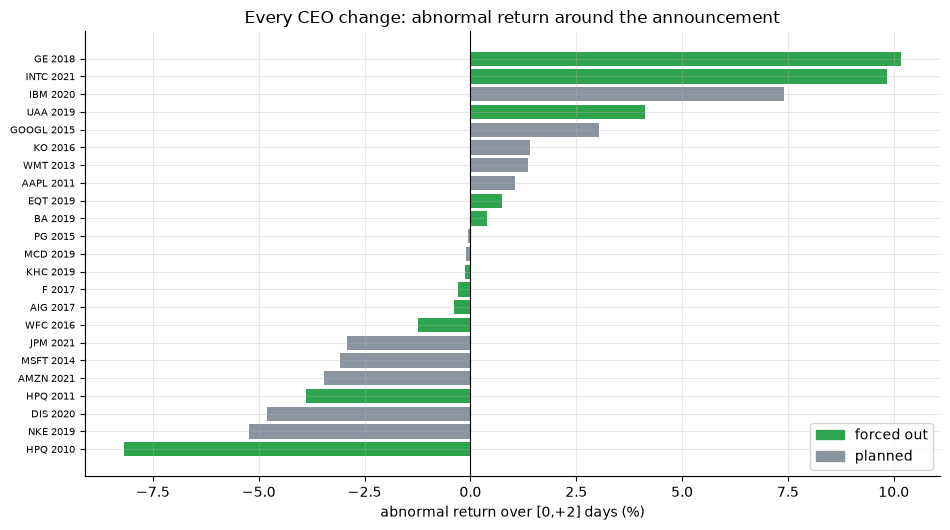

23 events; spread from -8.2% to 10.2% — no clean sign


In [2]:
if HAVE_REAL:
    p = PANEL.sort_values('car')
    cars = p['car'].values*100; cols = [GREEN if f else GREY for f in p['forced']]
    labs = [f"{t} {d.year}" for t,d in zip(p['ticker'], p['announce_date'])]
else:
    cars = np.array([-8.2,-5.2,-4.8,-3.9,-3.5,-3.1,-2.9,-1.2,-0.4,-0.3,-0.1,-0.1,0.7,1.0,1.1,1.4,1.4,3.0,3.9,4.1,7.4,9.8,10.2])
    cols = [GREY]*len(cars); labs = ['']*len(cars)
fig, ax = plt.subplots(figsize=(9.6, 5.4))
y = np.arange(len(cars))
ax.barh(y, cars, color=cols)
ax.axvline(0, c='k', lw=.8)
ax.set_yticks(y); ax.set_yticklabels(labs, fontsize=7)
ax.set_xlabel('abnormal return over [0,+2] days (%)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GREEN,label='forced out'), Patch(color=GREY,label='planned')], loc='lower right')
ax.set_title('Every CEO change: abnormal return around the announcement')
plt.tight_layout(); plt.show()
print(f'{len(cars)} events; spread from {cars.min():.1f}% to {cars.max():.1f}% — no clean sign')

The cloud is the story: outcomes run from **−8%** to **+10%** in *both* camps. The forced average (+1.0%) is a touch positive, the planned average (-0.5%) a touch negative — but look how few dots there are, and how far they scatter. Now the key move: *when* does the reaction actually happen?

**Where the move hides — day one vs the days after.** Here's the forced camp's abnormal return measured two ways: just the **announcement day** (you can't trade this — you only see it at the close) vs the **holdable** 3-day window.

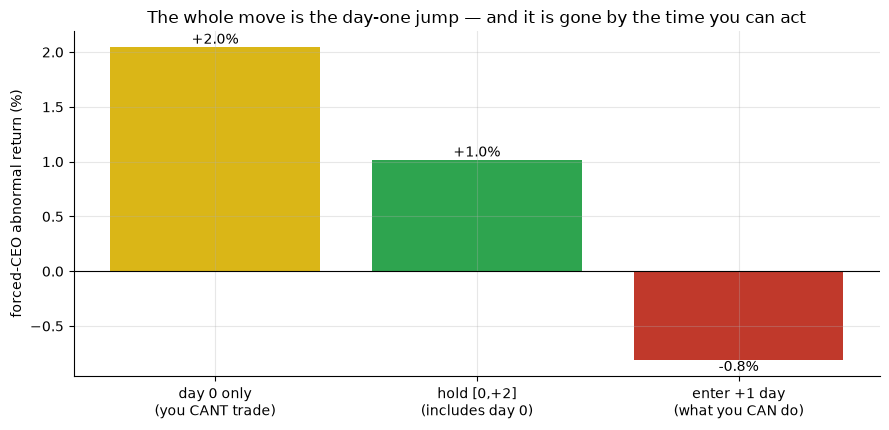

day0 +2.0%  ->  hold-from-next-day -0.8%  (the catchable part is nothing)


In [3]:
if HAVE_REAL:
    p00 = st.car_panel(PRICES, EVENTS, window=(0,0))
    f00 = p00.loc[p00['forced'],'car'].mean()*100
    f02 = PANEL.loc[PANEL['forced'],'car'].mean()*100
    plag = st.car_panel(PRICES, EVENTS, window=(0,2), lag=1)
    flag = plag.loc[plag['forced'],'car'].mean()*100
else:
    f00, f02, flag = R['day0'][0], R['forced'][1], R['lag1'][0]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
names = ['day 0 only\n(you CANT trade)', 'hold [0,+2]\n(includes day 0)', 'enter +1 day\n(what you CAN do)']
vals = [f00, f02, flag]; cols = [AMBER, GREEN, RED]
ax.bar(names, vals, color=cols)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('forced-CEO abnormal return (%)')
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('The whole move is the day-one jump — and it is gone by the time you can act')
plt.tight_layout(); plt.show()
print(f'day0 {f00:+.1f}%  ->  hold-from-next-day {flag:+.1f}%  (the catchable part is nothing)')

There it is. The forced-CEO stock pops **+2.0%** *on the announcement day* — a genuine, instant re-rating. But that's the price already adjusting to the news. Enter the **next** day, like a real trader must, and the move ahead of you is **-0.8%** — noise. The good news got priced while you were reading the headline.

**Could a dozen random windows look like the forced camp?** The honest small-sample test: draw 11 *random* (stock, date) windows over and over, and see where the actual forced average lands in the cloud of luck (canonical 3-day window).

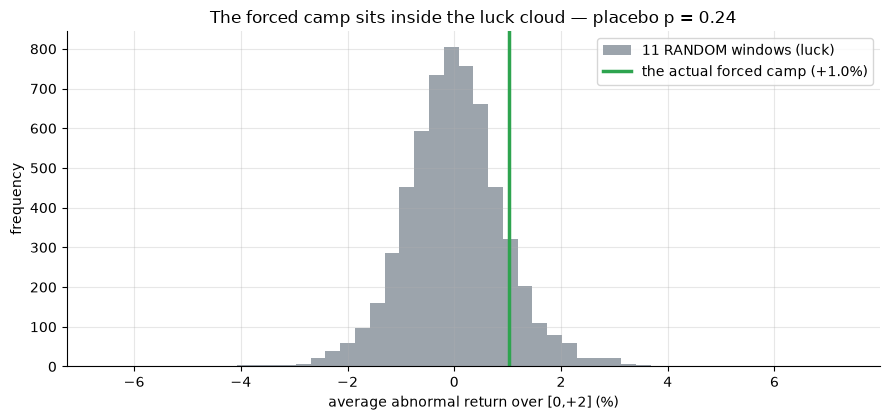

a random 11-window draw matches/beats the forced camp 24% of the time


In [4]:
if HAVE_REAL:
    f = PANEL.loc[PANEL['forced'],'car'].to_numpy()
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(f), n_draws=6000, seed=391)
    obs = f.mean(); pval = st.placebo_pvalue(obs, null)
else:
    rng=np.random.default_rng(391); null = rng.normal(0.0, 0.012, 6000)
    obs = R['forced'][1]/100; pval = R['forced_placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null*100, bins=50, color=GREY, alpha=.85, label='11 RANDOM windows (luck)')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'the actual forced camp ({obs*100:+.1f}%)')
ax.set_xlabel('average abnormal return over [0,+2] (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The forced camp sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random 11-window draw matches/beats the forced camp {pval*100:.0f}% of the time')

The green line — the real forced camp — sits **inside** the grey cloud (placebo *p* ≈ **0.25**). Over the window you could actually hold, the forced-CEO average is **what a handful of random dates produces anyway.** The day-one jump was real; the *tradable* part is not.

## 5 · The verdict

- **Signal — Weak.** A forced ouster *does* move the stock on day one (**+2.0%**, real) — but only on the day you can't trade. Over a holdable window forced is **+1.0%**, planned a shrug, and the gap between them (**+1.5pp**) is inside the noise. Real-as-a-day-one-reaction, weak-as-a-signal.
- **Tradability — Mirage.** The move is the instant the news hits. Enter the next day and you get **-0.8%** — worse after costs. Nothing to capture.
- **"Good news or bad news?" — Busted.** The only reliable move is the un-catchable day-one jump; the *holdable* drift is statistically zero in **both** directions. The clean fire-the-CEO trade doesn't exist.

## 6 · Could you actually trade it? — count the events

Forget significance for a second. How *many* shots does this give you, and how spread out are they? Here's the calendar of forced ousters — the punchline is how few there are.

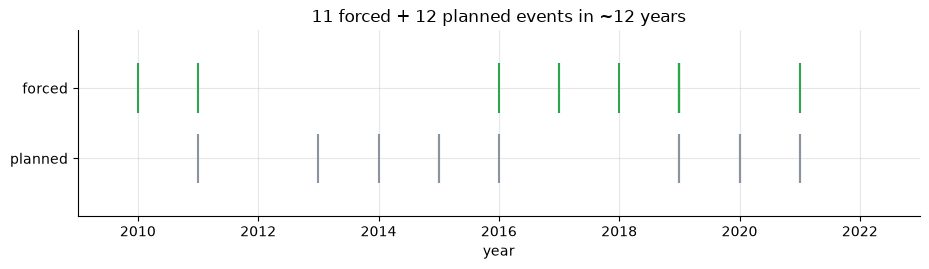

11 forced ousters total — about one a year, scattered. Too few to learn from, too instant to trade.


In [5]:
if HAVE_REAL:
    fy = [d.year for d,fo in zip(PANEL['announce_date'], PANEL['forced']) if fo]
    py = [d.year for d,fo in zip(PANEL['announce_date'], PANEL['forced']) if not fo]
else:
    fy=[2010,2011,2016,2017,2017,2018,2019,2019,2019,2021]; py=[2011,2013,2014,2015,2015,2016,2019,2020,2020,2021]
fig, ax = plt.subplots(figsize=(9.4, 2.8))
ax.eventplot(fy, colors=GREEN, lineoffsets=1, linelengths=.7, label='forced')
ax.eventplot(py, colors=GREY, lineoffsets=0, linelengths=.7, label='planned')
ax.set_yticks([0,1]); ax.set_yticklabels(['planned','forced']); ax.set_xlim(2009, 2023)
ax.set_title(f'{len(fy)} forced + {len(py)} planned events in ~12 years'); ax.set_xlabel('year')
plt.tight_layout(); plt.show()
print(f'{len(fy)} forced ousters total — about one a year, scattered. Too few to learn from, too instant to trade.')

About **11 forced ousters** of famous large-caps in a decade-plus. Even if each one carried a clean signal, that's not enough events to build a strategy on — and the signal *isn't* clean, and it fires before you can act. Three strikes: too **few**, too **noisy**, too **fast**.

## 7 · Going further 🚪

- **A frequent corporate event for contrast.** [Study 249 — Index-Inclusion](../249-index-inclusion/) runs the same event-study machinery on S&P additions — a *frequent* event with a measurable-but-tiny pop. Reading them together shows what rarity does to inference.
- **Another dated catalyst.** [Study 228 — Pre-Earnings-Runup](../228-pre-earnings-runup/) asks whether a *known, scheduled* event leaves a capturable drift.
- **Build your own.** Swap our hardcoded table for a bigger CEO-change list (or change the forced/planned calls) and re-run — more events tighten the error bars, but the day-one timing problem won't go away.

*Think there's a tradable fire-the-CEO edge? Show the forced camp landing **outside** the luck cloud on a window you could actually **hold from the next day** — then we'll talk.*